In [48]:
from spin_lattices import SpinLattice, KagomeLattice
from heisenberg_hamiltonians import HeisenbergJ1J2, SpinSystem
from pathlib import Path
from vmc_amplitude import get_csr_hamiltonian
from scipy.sparse import csr_matrix, diags, eye
import numpy as np
from scipy.sparse.linalg import eigsh
import scipy.sparse
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.linalg import eigh

In [3]:
lattice = KagomeLattice(2, 3)
system = HeisenbergJ1J2(lattice, 1, 1, use_symmetries=False, spin_inversion=None)
system.get_eigenstates(1)

2023-10-04 15:12:08.675 | DEBUG    | heisenberg_hamiltonians:__init__:472 - number_spins=18
2023-10-04 15:12:08.689 | DEBUG    | heisenberg_hamiltonians:__init__:482 - Symmetry group contains 0 elements
2023-10-04 15:12:08.691 | DEBUG    | heisenberg_hamiltonians:__init__:483 - Constructing basis
2023-10-04 15:12:08.758 | DEBUG    | heisenberg_hamiltonians:__init__:491 - Hilbert space dimension is 48620


2023-10-04 15:12:08.802 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:69 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-1.0-1.0-False-None-1.pickle
2023-10-04 15:12:08.842 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:117 - Ground state energy is -32.1930830942


(array([-32.19308309]),
 array([[ 4.67734071e-06],
        [ 4.05907513e-05],
        [-1.98695729e-05],
        ...,
        [ 1.98695729e-05],
        [-4.05907513e-05],
        [-4.67734071e-06]]))

In [4]:
H = get_csr_hamiltonian(system)

In [5]:
eigsh(H, which="SA", k=1)

(array([-32.19308309]),
 array([[ 4.67734071e-06],
        [ 4.05907513e-05],
        [-1.98695729e-05],
        ...,
        [ 1.98695729e-05],
        [-4.05907513e-05],
        [-4.67734071e-06]]))

In [6]:
ground_state = system.get_ground_state_coeffs(system.basis.states)
signs = np.sign(ground_state)
H_corrected = diags(signs) @ H @ diags(signs)

In [7]:
def overlap(x, y):
    return x @ y / (np.linalg.norm(x) * np.linalg.norm(y))

In [110]:
# signs = np.sign(ground_state)

signs = np.random.choice([-1, 1], size=ground_state.shape[0])

H_corrected = diags(signs) @ H @ diags(signs)
overlaps_power = []
for shift in [100]:
    M_shifted = shift * eye(H_corrected.shape[0]) - H_corrected

    x = np.random.uniform(0, 1, size=H_corrected.shape[0])
    noise_level = 0.0
    for i in range(200):
        # noise = np.random.uniform(-noise_level, noise_level, size=x.shape[0])
        x = M_shifted @ x
        x = x / np.linalg.norm(x)
        x = np.maximum(x, 0)
        print(i, overlap(x, np.abs(ground_state)))
        overlaps_power.append(
            {
                "shift": shift,
                "iteration": i,
                "amplitude_overlap": overlap(np.abs(x), np.abs(ground_state)),
                "zeroed_elements": np.sum(x == 0) / x.shape[0],
            }
        )

0 0.4140534072520653
1 0.4326646441673401
2 0.44856743628442375
3 0.46190570768869726
4 0.47300910977209343
5 0.4821207932018782
6 0.4894244331056031
7 0.49511555971861915
8 0.499657062727918
9 0.5031411115072182
10 0.5057324438112304
11 0.5074950100150577
12 0.5086349284362557
13 0.5092232568514584
14 0.5093938058626578
15 0.5091903174591629
16 0.508724645819321
17 0.5081014658593924
18 0.5073674661002737
19 0.5065523670193128
20 0.5056113551659336
21 0.5045649271378773
22 0.5033773447529193
23 0.5020989634743301
24 0.5007874134651108
25 0.49942519809382824
26 0.4980521749718104
27 0.49663062786135115
28 0.4951863401319233
29 0.4937044641236368
30 0.49219031135948416
31 0.49067100356840887
32 0.4891758088138493
33 0.4877026712179605
34 0.4862228895500203
35 0.48473489008052545
36 0.483231846609759
37 0.48175418831035
38 0.48028993820873156
39 0.47883437986899
40 0.47738723552561174
41 0.4759673003425819
42 0.47457113139390666
43 0.4731966633656218
44 0.4718386909683534
45 0.4705056268

In [90]:
x.shape

(48620,)

In [45]:
H = get_csr_hamiltonian(system)
H.shape

(48620, 48620)

In [104]:
M = get_csr_hamiltonian(system)
iterations = 100
keep_positive = True

_, ground_state = eigsh(M, which='SA', k=1)
ground_state = ground_state.flatten()

M_shifted = shift * eye(M.shape[0]) - M

overlaps_power = []

x = np.random.uniform(0, 1, size=M.shape[0])
print(x)
for i in range(iterations):
    x = np.asarray(M_shifted @ x.reshape(-1, 1)).reshape(-1)
    x = x / np.linalg.norm(x)
    if keep_positive:
        x = np.maximum(x, 0)
    overlaps_power.append(
        {
            "shift": shift,
            "iteration": i,
            "amplitude_overlap": overlap(np.abs(x), np.abs(ground_state)),
            "zeroed_elements": np.sum(x == 0) / x.shape[0],
        }
    )

[0.89753146 0.21705968 0.21770251 ... 0.18346671 0.66706764 0.20113768]


In [221]:
def power_method(
    M: np.ndarray | csr_matrix,
    shift: float,
    iterations: int = 500,
    keep_positive: bool = True,
    sign_correction: np.ndarray | None = None,
):
    true_energy, ground_state = eigsh(M, which="SA", k=1)
    ground_state = ground_state.flatten()
    true_energy = true_energy.flatten()[0]

    if sign_correction is not None:
        M_corrected = diags(sign_correction) @ M @ diags(sign_correction)
    else:
        M_corrected = M

    if isinstance(M, csr_matrix):
        M_shifted = shift * eye(M_corrected.shape[0]) - M_corrected
    else:
        M_shifted = shift * np.eye(M_corrected.shape[0]) - M_corrected

    overlaps_power = []

    x = np.random.uniform(0, 1, size=M_corrected.shape[0])
    x /= np.linalg.norm(x)
    xs = [x.copy()]
    for i in range(iterations):
        x = np.asarray(M_shifted @ x.reshape(-1, 1)).reshape(-1)
        
        if keep_positive:
            x = np.maximum(x, 0)
            
        x = x / np.linalg.norm(x)
        
        xs.append(x.copy())

        energy = (x @ M_corrected @ x) / (x @ x)

        overlaps_power.append(
            {
                "shift": shift,
                "iteration": i,
                "amplitude_overlap": overlap(np.abs(x), np.abs(ground_state)),
                "zeroed_elements": np.sum(x == 0) / x.shape[0],
                "energy": energy,
                "energy_error": np.abs(energy - true_energy),
                "relative_energy_error": np.abs(energy - true_energy) / np.abs(true_energy),
            }
        )
    xs = np.asarray(xs)
    return overlaps_power, xs, ground_state

In [243]:
# M = np.random.uniform(-1, 1, size=(1024 * 4, 1024 * 4))
# M = M + M.T
M = get_csr_hamiltonian(system)
sign_correction = None # np.random.choice([-1, 1], size=M.shape[0], p=[0.5, 0.5])
overlaps_power, xs, ground_state = power_method(
    M,
    shift=250.0,
    iterations=500,
    keep_positive=True,
    sign_correction=sign_correction,
)

/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


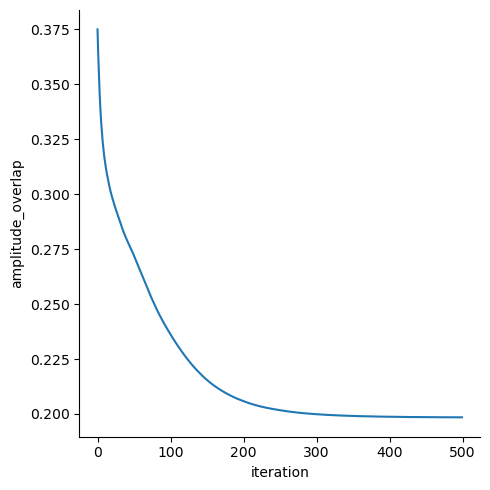

In [244]:
sns.relplot(
    pd.DataFrame(overlaps_power),
    x="iteration",
    y="amplitude_overlap",
#    row="variable",
    #    hue="shift",
    #hue='variable',
    kind="line",
    facet_kws={"sharey": False, "sharex": True},
)

In [223]:
all_xs = []
for tr in range(5):
    sign_correction = np.random.choice([-1, 1], size=M.shape[0], p=[0.5, 0.5])
    overlaps_power, xs, ground_state = power_method(
        M,
        shift=250.0,
        iterations=500,
        keep_positive=True,
        sign_correction=sign_correction,
    )
    all_xs.append(xs)
all_xs = np.asarray(all_xs)

In [231]:
all_xs[0, 100] @ np.abs(system.get_ground_state())

0.4923731065533232

In [233]:
all_xs[0, 100] @ all_xs[1, 100]

0.3598881480222355

In [234]:
all_xs[0, 100] @ all_xs[2, 100]

0.3749868883864539

In [237]:
(all_xs[0, 100] >= 0).all()

True

/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


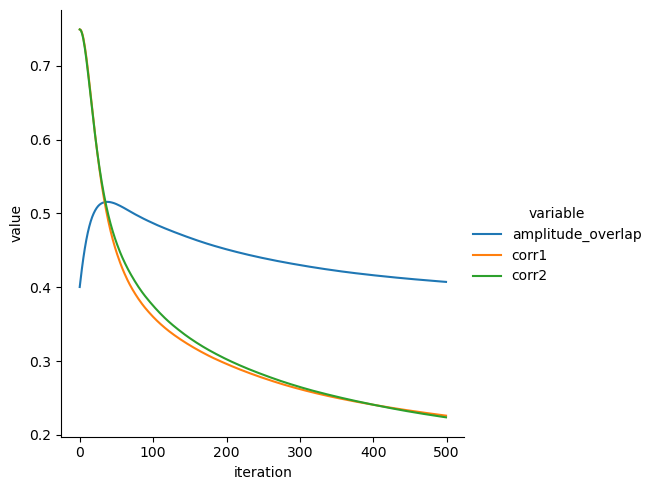

In [226]:
sns.relplot(
    pd.DataFrame(overlaps_power)
    .assign(corr1=np.einsum("itj,ktj->itk", all_xs, all_xs)[0, :-1, 1],
            corr2=np.einsum("itj,ktj->itk", all_xs, all_xs)[0, :-1, 2]
    )
    .melt(
        id_vars=["iteration"],
        value_vars=[
            "amplitude_overlap",
            # "energy",
            # "energy_error",
            # "relative_energy_error",
            "corr1",
            "corr2",
        ],
    ),
    x="iteration",
    y="value",
#    row="variable",
    #    hue="shift",
    hue='variable',
    kind="line",
    facet_kws={"sharey": False, "sharex": True},
)

In [165]:
(x != 0).sum() / x.shape[0]

0.5068696009872481

In [168]:
((system.get_ground_state() > 0) == (x > 0)).mean()

0.4981283422459893

array([ True,  True, False, ..., False, False, False])

In [9]:
signs = np.sign(ground_state)
H_corrected = diags(signs) @ H @ diags(signs)
M_shifted = 50 * eye(H_corrected.shape[0]) - H_corrected
psi_0 = np.random.uniform(0, 1, size=H_corrected.shape[0])
psi_0 = psi_0 / np.linalg.norm(psi_0)
overlaps_lanczos = []

for i in range(200):
    H_psi_0 = M_shifted @ psi_0
    psi_1 = H_psi_0
    psi_1 = psi_1 - psi_1 @ psi_0 * psi_0
    psi_1 = psi_1 / np.linalg.norm(psi_1)

    H_psi_1 = M_shifted @ psi_1
    a11 = psi_0 @ H_psi_0
    a12 = psi_0 @ H_psi_1
    a22 = psi_1 @ H_psi_1

    H_restricted = np.array([[a11, a12], [a12, a22]])
    eigenvalues, eigenvectors = np.linalg.eigh(H_restricted)
    # print(eigenvalues, eigenvectors)

    psi_0 = eigenvectors[0, 1] * psi_0 + eigenvectors[1, 1] * psi_1
    psi_0 = psi_0 / np.linalg.norm(psi_0)
    psi_0 = np.abs(psi_0)

    print(i, overlap(psi_0, np.abs(ground_state)))
    overlaps_lanczos.append(overlap(psi_0, np.abs(ground_state)))

0 0.7130578410786514
1 0.892832549508928
2 0.9433937551523347
3 0.9695092079699288
4 0.9792538479885003
5 0.9859604941679038
6 0.9889364053110146
7 0.9912452211850953
8 0.9924986100555452
9 0.9934908477197487
10 0.9941568473892577
11 0.9946888828187056
12 0.9950979924915165
13 0.9954386249263892
14 0.9957190621026583
15 0.9959630648881848
16 0.9961729203306999
17 0.9963610302144945
18 0.9965277004759858
19 0.9966800750136722
20 0.9968180178643407
21 0.9969458380794055
22 0.9970632436481158
23 0.997173078949416
24 0.9972749947362367
25 0.9973709468647591
26 0.9974606709986542
27 0.9975455836627563
28 0.9976254400137994
29 0.9977013149807702
30 0.997772978038124
31 0.9978412741055342
32 0.9979060136740947
33 0.9979678550575837
34 0.9980266576925011
35 0.9980829310613797
36 0.9981365651332155
37 0.998187983373808
38 0.9982370893445145
39 0.9982842399019061
40 0.9983293431063524
41 0.9983727095957986
42 0.9984142558118012
43 0.9984542569010019
44 0.9984926317294159
45 0.9985296291234992
46

In [13]:
def expected_value(x, H):
    return x @ H @ x / (x @ x)

In [19]:
signs = np.sign(ground_state)
H_corrected = diags(signs) @ H @ diags(signs)
# H_corrected_shifted = 50 * eye(H_corrected.shape[0]) - H_corrected
psi_0 = np.random.uniform(0, 1, size=H_corrected.shape[0])
psi_0 = psi_0 / np.linalg.norm(psi_0)
psi_0 *= 10
overlaps_lanczos_chen = []

for i in range(200):
    v = np.sqrt(expected_value(psi_0, H_corrected **2) - expected_value(psi_0, H_corrected) ** 2)

    H_psi_0 = H_corrected @ psi_0    
    psi_1 = H_psi_0
    psi_1 = psi_1 - expected_value(psi_0, H_corrected) * psi_0
    psi_1 = psi_1 / v
    # assert np.isclose(np.linalg.norm(psi_1), 1)

    r = (
        expected_value(psi_0, H_corrected**3)
        - 3 * expected_value(psi_0, H_corrected ** 2) * expected_value(psi_0, H_corrected)
        + 2 * expected_value(psi_0, H_corrected) ** 3
    )
    r = r / (2 * v**3)
    alpha = r - np.sqrt((r**2 + 1))

    psi_0 = psi_0 / np.sqrt(1 + alpha**2) + psi_1 * alpha / np.sqrt(1 + alpha**2)
    psi_0 = np.abs(psi_0)

    print(i, overlap(psi_0, np.abs(ground_state)), alpha)
    overlaps_lanczos_chen.append(overlap(psi_0, np.abs(ground_state)))

0 0.7068724554484784 -0.9706005686441197
1 0.8877611766715781 -0.518022964308146
2 0.9406290289837126 -0.22467073313658759
3 0.968582131433966 -0.15071458305866914
4 0.97898619821308 -0.08390030754362954
5 0.986210790419649 -0.06663099517600113
6 0.9893453015292154 -0.0417235068201407
7 0.9918117964916604 -0.035142196037377005
8 0.9930970105910729 -0.02504849642185647
9 0.9941310897202797 -0.021055897968143
10 0.9947965629993188 -0.017119988825687216
11 0.9953276318413613 -0.014451523423524293


KeyboardInterrupt: 

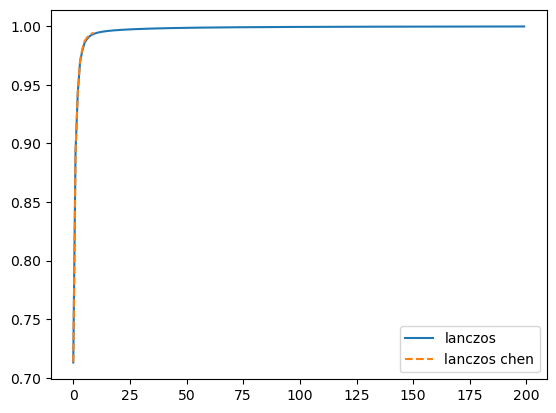

In [18]:
#plt.plot(overlaps_power, label="power")
plt.plot(overlaps_lanczos, label="lanczos")
plt.plot(overlaps_lanczos_chen, '--', label="lanczos chen")
plt.legend()

In [ ]:
def E_loc(H, psi):
    return H @ psi / psi

In [ ]:
psi_test = np.random.uniform(-1, 1, system.basis.states.shape[0])

In [ ]:
psi_test.shape

(48620,)

In [ ]:
def expected_value(H, psi):
    return (psi @ (H @ psi)) / (psi @ psi)

In [ ]:
E_loc(system.hamiltonian, psi_test) @ (psi_test ** 2) / (psi_test @ psi_test)

[Debug]   [LOCALE0]   remoteBufferSize: 150000; numChunks: 320; batchedOperatorChunkSize: 152


-2.1157033458052013

In [ ]:
expected_value(system.hamiltonian, psi_test)

[Debug]   [LOCALE0]   remoteBufferSize: 150000; numChunks: 320; batchedOperatorChunkSize: 152


-2.115703345805201

In [ ]:
expected_value(system.hamiltonian ** 2, psi_test)

[Debug]   [LOCALE0]   remoteBufferSize: 150000; numChunks: 320; batchedOperatorChunkSize: 152
[Debug]   [LOCALE0]   remoteBufferSize: 150000; numChunks: 320; batchedOperatorChunkSize: 152


110.56163797860157

In [ ]:
(E_loc(system.hamiltonian, psi_test) ** 2) @ (psi_test ** 2) / (psi_test @ psi_test)

[Debug]   [LOCALE0]   remoteBufferSize: 150000; numChunks: 320; batchedOperatorChunkSize: 152


110.56163797860158

In [ ]:
expected_value(system.hamiltonian ** 3, psi_test)

[Debug]   [LOCALE0]   remoteBufferSize: 150000; numChunks: 320; batchedOperatorChunkSize: 152
[Debug]   [LOCALE0]   remoteBufferSize: 150000; numChunks: 320; batchedOperatorChunkSize: 152
[Debug]   [LOCALE0]   remoteBufferSize: 150000; numChunks: 320; batchedOperatorChunkSize: 152


-660.4831949098275

In [ ]:
(E_loc(system.hamiltonian, psi_test) ** 3) @ (psi_test ** 2) / (psi_test @ psi_test)

[Debug]   [LOCALE0]   remoteBufferSize: 150000; numChunks: 320; batchedOperatorChunkSize: 152


-1064.089705216408